# Barra Simples – Formulação do Problema

Deslocamento axial de um ponto da barra:
$$
u=u(x,t)
$$ 

Massa por unidade de comprimento da barra:
$$
m=\rho A.
$$

---

## Elemento infinitesimal

<img src="Elemento.png" width="300" style="display: block; margin-left: auto; margin-right: auto;">

## 1. Condição de equilíbrio de forças

$$
-\sigma A + (\sigma+d\sigma)A
+q(x,t)\,dx
-k\,u(x,t)\,dx
-\rho A\,dx\,\frac{\partial^2u}{\partial t^2}
=0
$$

Simplificando a equação de equilíbrio:

$$
A\,d\sigma
+q(x,t)\,dx
-k\,u(x,t)\,dx
-\rho A\,dx\,\frac{\partial^2u}{\partial t^2}
=0
$$

Dividindo por $A\,dx$, chega-se a forma forte:

$$
\boxed{
\frac{\partial \sigma}{\partial x}
-\rho\frac{\partial^2u}{\partial t^2}
=
-\frac{q(x,t)-k\,u(x,t)}{A}
}
$$



## 2. Condições de contorno

$$
\boxed{u(0,t)=0}
$$

$$
\boxed{\sigma(L,t)=\frac{P(t)}{A}}
$$

ou, em termos da força normal,

$$
\boxed{N(L,t)=P(t)}
$$


## 3. Caso estático e sem molas

$$
k=0
\qquad \text{(sem molas)}
$$

$$
\rho=0
\qquad \text{(problema estático)}
$$

Além disso,

$$
P=\text{constante}
\qquad\text{e}\qquad
q=q(x)
$$

A forma forte fica então:

$$
\boxed{
\frac{d\sigma}{dx}+\frac{q(x)}{A}=0
}
$$

Portanto, o problema de valor de contorno é

$$
\boxed{
\begin{cases}
\dfrac{d\sigma}{dx}+\dfrac{q(x)}{A}=0, & 0<x<L,\\[6pt]
u(0)=0,\\[4pt]
\sigma(L)=\dfrac{P}{A}.
\end{cases}
}
$$

## 4. Compatibilidade e relação constitutiva

Considerando o regime de **pequenas deformações**, a condição de compatibilidade entre deslocamento e deformação é

$$
\boxed{
\varepsilon=\frac{du}{dx}
}
$$

Adota-se agora um **material elástico não linear**, descrito pela seguinte relação constitutiva:

$$
\boxed{
\sigma=E_0\left(\varepsilon-5\varepsilon^2\right)
}
$$


## 5. Forma forte em termos dos deslocamentos

Substituindo a relação constitutiva e a condição de compatibilidade, obtém-se:

$$
\boxed{
\frac{d}{dx}
\left[
E_0
\left(
\frac{du}{dx}
-
5\left(\frac{du}{dx}\right)^2
\right)
\right]
+
\frac{q(x)}{A}
=0
}
$$

Para $E_0$ constante, realizando a derivada:

$$
E_0
\left(
1-10\frac{du}{dx}
\right)
\frac{d^2u}{dx^2}
+
\frac{q(x)}{A}
=0.
$$

Portanto,

$$
\boxed{
E_0
\left(
1-10\frac{du}{dx}
\right)
\frac{d^2u}{dx^2}
+
\frac{q(x)}{A}
=0
}
$$

com as condições de contorno

$$
u(0)=0
$$

e

$$
\sigma(L)=\frac{P}{A}.
$$

A condição natural também pode ser escrita em termos do deslocamento:

$$
\boxed{
E_0
\left[
\frac{du}{dx}
-
5\left(\frac{du}{dx}\right)^2
\right]_{x=L}
=
\frac{P}{A}
}
$$

## 6. Solução fechada para uma carga $P$ qualquer


$$
\sigma=E_0\left(\varepsilon-5\varepsilon^2\right),
$$

Logo:

$$
\frac{P}{A}=E_0\left(\varepsilon-5\varepsilon^2\right).
$$

Reorganizando,

$$
5\varepsilon^2-\varepsilon+\frac{P}{AE_0}=0.
$$

Aplicando a fórmula de Bhaskara:

$$
\boxed{
\varepsilon=
\frac{1\pm\sqrt{1-\dfrac{20P}{AE_0}}}{10}
}
$$

No ramo físico que parte de $\varepsilon=0$ quando $P=0$, deve-se adotar o sinal negativo:

$$
\boxed{
\varepsilon=
\frac{1-\sqrt{1-\dfrac{20P}{AE_0}}}{10}
}
$$

Como

$$
\varepsilon=\frac{du}{dx},
$$

e a deformação é constante ao longo da barra,

$$
u(x)=\varepsilon x.
$$

Portanto, a solução fechada para o campo de deslocamentos é

$$
\boxed{
u(x)=
\frac{x}{10}
\left(
1-\sqrt{1-\frac{20P}{AE_0}}
\right)
}
$$

com

$$
0\leq x\leq L.
$$

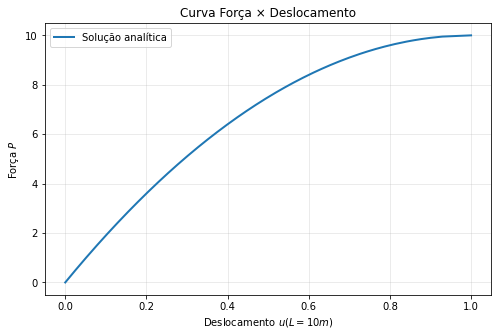

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
A = 1.0
E0 = 200.0
L = 10.0

# Carga limite
Pmax = A * E0 / 20

# Valores de força
P = np.linspace(0, Pmax, 200)

# Deslocamento na extremidade x = L
uL = (L / 10) * (1 - np.sqrt(1 - (20 * P) / (A * E0)))

# Curva Força x Deslocamento
plt.figure(figsize=(8, 5))

plt.plot(uL, P, linewidth=2, label='Solução analítica')

plt.xlabel(r'Deslocamento $u(L=10m)$')
plt.ylabel(r'Força $P$')
plt.title('Curva Força × Deslocamento')

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

## 7. Forma fraca do problema

Para obter uma solução numérica pelo Método dos Elementos Finitos, parte-se da **forma fraca** do problema:

$$
\int_0^L
\sigma A
\frac{d\delta u}{dx}\,dx
=
P\,\delta u(L)
+
\int_0^L
q\,\delta u\,dx
$$

para todo deslocamento virtual $\delta u(x)$ admissível e homogêneo nas condições de contorno essenciais.

Substituindo a relação constitutiva

$$
\sigma=E_0\left(\varepsilon-5\varepsilon^2\right),
$$

resulta

$$
\int_0^L
E_0A
\left(\varepsilon-5\varepsilon^2\right)
\frac{d\delta u}{dx}\,dx
=
P\,\delta u(L)
+
\int_0^L
q\,\delta u\,dx.
$$

Finalmente, utilizando a condição de compatibilidade

$$
\varepsilon=\frac{du}{dx},
$$

obtém-se

$$
\boxed{
\int_0^L
E_0A
\left[
\frac{du}{dx}
-
5\left(\frac{du}{dx}\right)^2
\right]
\frac{d\delta u}{dx}\,dx
=
P\,\delta u(L)
+
\int_0^L
q\,\delta u\,dx
}
$$

Considere um elemento finito unidimensional de comprimento $L^e$, com dois nós e deslocamentos nodais

$$
u_1^e
\qquad\text{e}\qquad
u_2^e.
$$

A forma fraca do problema, restrita ao domínio do elemento, é

$$
\int_0^{L^e}
\sigma A
\frac{d\,\delta u^e}{dx}
\,dx
=
\mathbf{F}^{eT}\delta\mathbf{u}^e
+
\int_0^{L^e}
q(x)\,\delta u^e\,dx.
$$

Utilizando a relação constitutiva

$$
\sigma
=
E_0
\left(
\varepsilon-5\varepsilon^2
\right),
$$

e a condição de compatibilidade

$$
\varepsilon=\frac{du^e}{dx},
$$

obtém-se

$$
\boxed{
\int_0^{L^e}
E_0A
\left[
\frac{du^e}{dx}
-
5\left(\frac{du^e}{dx}\right)^2
\right]
\frac{d\,\delta u^e}{dx}
\,dx
=
\mathbf{F}^{eT}\delta\mathbf{u}^e
+
\int_0^{L^e}
q(x)\,\delta u^e\,dx
}
$$

## 8. Substituição das aproximações na forma fraca

Pelo método de Galerkin:

$$
u^e(x)=\phi_i(x)u_i^e
$$

e

$$
\delta u^e(x)=\phi_j(x)\delta u_j^e.
$$

Portanto,

$$
\frac{du^e}{dx}
=
\phi_i'(x)u_i^e
$$

e

$$
\frac{d\delta u^e}{dx}
=
\phi_j'(x)\delta u_j^e.
$$

Substituindo essas aproximações na forma fraca:

$$
\int_0^{L^e}
E_0A
\left(
1-5\phi_i'u_i^e
\right)
\phi_k'u_k^e
\phi_j'\delta u_j^e
\,dx
=
F_j\delta u_j^e
+
\int_0^{L^e}
q\phi_j\delta u_j^e\,dx.
$$

Colocando as variações nodais $\delta u_j^e$ em evidência:

$$
\left\{
\int_0^{L^e}
E_0A
\left(
1-5\phi_i'u_i^e
\right)
\phi_k'\phi_j'
\,dx
\right\}
u_k^e\delta u_j^e
=
\left[
F_j
+
\int_0^{L^e}q\phi_j\,dx
\right]
\delta u_j^e.
$$

Como as variações $\delta u_j^e$ são arbitrárias:

$$
\boxed{
\int_0^{L^e}
E_0A
\left(
1-5\phi_i'u_i^e
\right)
\phi_k'\phi_j'
\,dx
\;u_k^e
=
F_j
+
\int_0^{L^e}q\phi_j\,dx
}
$$

Definindo

$$
K_{jk}^e(\mathbf{u}^e)
=
\int_0^{L^e}
E_0A
\left(
1-5\phi_i'u_i^e
\right)
\phi_k'\phi_j'
\,dx,
$$

obtém-se o sistema não linear

$$
\boxed{
\mathbf{K}^e(\mathbf{u}^e)\mathbf{u}^e
=
\mathbf{F}^e
}
$$

Agora fica claro o papel de cada índice:

i: aparece dentro do termo não linear e faz $K$ depender de u; 

k: identifica a coluna da matriz $K_jk$ e multiplica $u_k$;

j: identifica a linha/equação, associada à função peso $ϕ_j$.

## 9. Elemento linear de dois nós

Para um elemento finito de dois nós, adotam-se as funções de forma lineares

$$
\phi_1(x)=1-\frac{x}{L^e}
$$

e

$$
\phi_2(x)=\frac{x}{L^e}.
$$

Suas derivadas são constantes:

$$
\phi_1'=-\frac{1}{L^e},
\qquad
\phi_2'=\frac{1}{L^e}.
$$

Assim,

$$
\mathbf{B}
=
\begin{bmatrix}
-\dfrac{1}{L^e} & \dfrac{1}{L^e}
\end{bmatrix}.
$$

A deformação no elemento é

$$
\varepsilon^e
=
\phi_1'u_1^e+\phi_2'u_2^e,
$$

portanto,

$$
\boxed{
\varepsilon^e
=
\frac{u_2^e-u_1^e}{L^e}
}
$$

e é constante ao longo do elemento.

A matriz do elemento é definida por

$$
K_{jk}^e
=
\int_0^{L^e}
E_0A
\left(
1-5\varepsilon^e
\right)
\phi_k'\phi_j'
\,dx.
$$

Como $E_0$, $A$, $\varepsilon^e$ e as derivadas das funções de forma são constantes no elemento,

$$
K_{jk}^e
=
E_0A
\left(
1-5\varepsilon^e
\right)
\int_0^{L^e}
\phi_k'\phi_j'\,dx.
$$

Utilizando

$$
\varepsilon^e=
\frac{u_2^e-u_1^e}{L^e},
$$

obtém-se

$$
\boxed{
\mathbf{K}^e(\mathbf{u}^e)
=
\frac{E_0A}{L^e}
\left[
1-
5\left(
\frac{u_2^e-u_1^e}{L^e}
\right)
\right]
\begin{bmatrix}
1 & -1\\
-1 & 1
\end{bmatrix}
}
$$

## 10. Sistema de equações do elemento

O vetor de deslocamentos nodais do elemento é

$$
\boxed{
\mathbf{u}^e
=
\begin{Bmatrix}
u_1^e\\
u_2^e
\end{Bmatrix}
}
$$

A matriz não linear do elemento é

$$
\boxed{
\mathbf{K}^e(\mathbf{u}^e)
=
\frac{E_0A}{L^e}
\left[
1-
5\left(
\frac{u_2^e-u_1^e}{L^e}
\right)
\right]
\begin{bmatrix}
1 & -1\\
-1 & 1
\end{bmatrix}
}
$$

Para um carregamento distribuído uniforme $q$, o vetor de forças nodais equivalentes é

$$
\boxed{
\mathbf{F}^e
=
\begin{Bmatrix}
F_1+\dfrac{qL^e}{2}\\[6pt]
F_2+\dfrac{qL^e}{2}
\end{Bmatrix}
}
$$

Portanto, o sistema de equações do elemento é

$$
\boxed{
\frac{E_0A}{L^e}
\left[
1-
5\left(
\frac{u_2^e-u_1^e}{L^e}
\right)
\right]
\begin{bmatrix}
1 & -1\\
-1 & 1
\end{bmatrix}
\begin{Bmatrix}
u_1^e\\
u_2^e
\end{Bmatrix}
=
\begin{Bmatrix}
F_1+\dfrac{qL^e}{2}\\[6pt]
F_2+\dfrac{qL^e}{2}
\end{Bmatrix}
}
$$

Como a matriz depende de $u_1^e$ e $u_2^e$, o sistema é **não linear**.

## 11. Discretização da barra em dois elementos

A barra de comprimento total $L$ é discretizada em dois elementos lineares de mesmo comprimento:

$$
L^1=L^2=\frac{L}{2}.
$$

A estrutura possui três nós globais, com os seguintes deslocamentos:

$$
\mathbf{U}
=
\begin{Bmatrix}
U_1\\
U_2\\
U_3
\end{Bmatrix}.
$$

A conectividade dos elementos é:

- Elemento 1: nós globais $1-2$;
- Elemento 2: nós globais $2-3$.

Assim, os vetores de deslocamentos locais são

$$
\mathbf{u}^1=
\begin{Bmatrix}
U_1\\
U_2
\end{Bmatrix}
$$

e

$$
\mathbf{u}^2=
\begin{Bmatrix}
U_2\\
U_3
\end{Bmatrix}.
$$

### Matriz do elemento 1

Para um elemento genérico,

$$
\mathbf{K}^e
=
\frac{E_0A}{L^e}
\left[
1-
5\left(
\frac{u_2^e-u_1^e}{L^e}
\right)
\right]
\begin{bmatrix}
1 & -1\\
-1 & 1
\end{bmatrix}.
$$

Como

$$
L^1=\frac{L}{2},
$$

a deformação no elemento 1 é

$$
\varepsilon^1
=
\frac{U_2-U_1}{L/2}
=
2\frac{U_2-U_1}{L}.
$$

Portanto,

$$
\boxed{
\mathbf{K}^1
=
\frac{2E_0A}{L}
\left[
1-
10\left(
\frac{U_2-U_1}{L}
\right)
\right]
\begin{bmatrix}
1 & -1\\
-1 & 1
\end{bmatrix}
}
$$

Definindo

$$
a_1=
1-
10\left(
\frac{U_2-U_1}{L}
\right),
$$

podemos escrever

$$
\mathbf{K}^1
=
\frac{2E_0A}{L}
a_1
\begin{bmatrix}
1 & -1\\
-1 & 1
\end{bmatrix}.
$$

### Matriz do elemento 2

Para o segundo elemento,

$$
\varepsilon^2
=
\frac{U_3-U_2}{L/2}
=
2\frac{U_3-U_2}{L}.
$$

Logo,

$$
\boxed{
\mathbf{K}^2
=
\frac{2E_0A}{L}
\left[
1-
10\left(
\frac{U_3-U_2}{L}
\right)
\right]
\begin{bmatrix}
1 & -1\\
-1 & 1
\end{bmatrix}
}
$$

Definindo

$$
a_2=
1-
10\left(
\frac{U_3-U_2}{L}
\right),
$$

tem-se

$$
\mathbf{K}^2
=
\frac{2E_0A}{L}
a_2
\begin{bmatrix}
1 & -1\\
-1 & 1
\end{bmatrix}.
$$

In [10]:
import sympy as sp
from IPython.display import display, Math

# ============================================================
# VARIÁVEIS SIMBÓLICAS
# ============================================================

E0, A, L = sp.symbols('E_0 A L', positive=True)
U1, U2, U3 = sp.symbols('U_1 U_2 U_3')

sp.init_printing()

# ============================================================
# COMPRIMENTO DOS ELEMENTOS
# ============================================================

Le = L / 2

# ============================================================
# TERMOS NÃO LINEARES
# ============================================================

a1 = 1 - 10*(U2 - U1)/L
a2 = 1 - 10*(U3 - U2)/L

display(Math(r'a_1 = ' + sp.latex(a1)))
display(Math(r'a_2 = ' + sp.latex(a2)))

# ============================================================
# MATRIZ DO ELEMENTO 1
# Elemento 1: nós globais 1 - 2
# ============================================================

K1 = (E0*A/Le) * a1 * sp.Matrix([
    [ 1, -1],
    [-1,  1]
])

display(Math(r'\mathbf{K}^{1} = ' + sp.latex(K1)))

# ============================================================
# MATRIZ DO ELEMENTO 2
# Elemento 2: nós globais 2 - 3
# ============================================================

K2 = (E0*A/Le) * a2 * sp.Matrix([
    [ 1, -1],
    [-1,  1]
])

display(Math(r'\mathbf{K}^{2} = ' + sp.latex(K2)))

# ============================================================
# MONTAGEM DA MATRIZ GLOBAL
# ============================================================

K_global = sp.zeros(3, 3)

# Conectividades
gdls1 = [0, 1]   # elemento 1 -> nós 1 e 2
gdls2 = [1, 2]   # elemento 2 -> nós 2 e 3

# Montagem do elemento 1
for i in range(2):
    for j in range(2):
        K_global[gdls1[i], gdls1[j]] += K1[i, j]

# Montagem do elemento 2
for i in range(2):
    for j in range(2):
        K_global[gdls2[i], gdls2[j]] += K2[i, j]

K_global = sp.simplify(K_global)

display(Math(r'\mathbf{K}_{global} = ' + sp.latex(K_global)))

# ============================================================
# FORMA COMPACTA ESPERADA
# ============================================================

K_compacta = (2*E0*A/L) * sp.Matrix([
    [ a1,      -a1,       0],
    [-a1,  a1 + a2,    -a2],
    [   0,      -a2,      a2]
])

#display(Math(r'\mathbf{K}_{compacta} = ' + sp.latex(K_compacta)))

# ============================================================
# VERIFICAÇÃO
# ============================================================

#verificacao = sp.simplify(K_global - K_compacta)

#display(Math(r'\mathbf{K}_{global} - \mathbf{K}_{compacta} ='))
#display(verificacao)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 13. Vetor global de forças

Para o elemento 1,

$$
\mathbf{F}^1
=
\begin{Bmatrix}
R+\dfrac{qL}{4}\\[6pt]
\dfrac{qL}{4}
\end{Bmatrix},
$$

e, para o elemento 2,

$$
\mathbf{F}^2
=
\begin{Bmatrix}
\dfrac{qL}{4}\\[6pt]
P+\dfrac{qL}{4}
\end{Bmatrix}.
$$

Após a montagem:

$$
\boxed{
\mathbf{F}
=
\begin{Bmatrix}
R+\dfrac{qL}{4}\\[8pt]
\dfrac{qL}{2}\\[8pt]
P+\dfrac{qL}{4}
\end{Bmatrix}
}
$$

O sistema global não linear é, portanto,

$$
\boxed{
\mathbf{K}(\mathbf{U})\mathbf{U}
=
\mathbf{F}.
}
$$

In [11]:
import sympy as sp
from IPython.display import display, Math

# ============================================================
# VARIÁVEIS SIMBÓLICAS
# ============================================================

E0, A, L = sp.symbols('E_0 A L', positive=True)
U1, U2, U3 = sp.symbols('U_1 U_2 U_3')
R, P, q = sp.symbols('R P q')

sp.init_printing()

# ============================================================
# TERMOS NÃO LINEARES DOS ELEMENTOS
# ============================================================

a1 = 1 - 10*(U2 - U1)/L
a2 = 1 - 10*(U3 - U2)/L

# ============================================================
# MATRIZ GLOBAL
# ============================================================

K = (2*E0*A/L) * sp.Matrix([
    [ a1,       -a1,       0],
    [-a1,   a1 + a2,    -a2],
    [   0,       -a2,      a2]
])

# ============================================================
# VETOR DE DESLOCAMENTOS
# ============================================================

U = sp.Matrix([
    U1,
    U2,
    U3
])

# ============================================================
# VETOR GLOBAL DE FORÇAS
# ============================================================
# Cada elemento possui comprimento Le = L/2
# Logo, q*Le/2 = qL/4

F = sp.Matrix([
    R + q*L/4,
    q*L/2,
    P + q*L/4
])

# ============================================================
# EXIBIÇÃO DO SISTEMA
# ============================================================

display(
    Math(
        sp.latex(K)
        + sp.latex(U)
        + "="
        + sp.latex(F)
    )
)

<IPython.core.display.Math object>

## 14. Solução do sistema não linear para dois elementos

Considerando os dados do problema

$$
E_0=200,
\qquad
A=1,
\qquad
L=10,
\qquad
q=0,
$$

e a condição de contorno essencial

$$
\boxed{U_1=0},
$$

a barra é discretizada em dois elementos de comprimento

$$
L^e=\frac{L}{2}=5.
$$

Os termos não lineares associados aos elementos são

$$
a_1
=
1-10\frac{U_2-U_1}{L}
$$

e

$$
a_2
=
1-10\frac{U_3-U_2}{L}.
$$

Como $U_1=0$ e $L=10$,

$$
\boxed{a_1=1-U_2}
$$

e

$$
\boxed{a_2=1-U_3+U_2}.
$$

A matriz global não linear é

$$
\mathbf{K}(\mathbf{U})
=
\frac{2E_0A}{L}
\begin{bmatrix}
a_1 & -a_1 & 0\\
-a_1 & a_1+a_2 & -a_2\\
0 & -a_2 & a_2
\end{bmatrix}.
$$

Substituindo os valores de $E_0$, $A$ e $L$:

$$
\boxed{
\mathbf{K}(\mathbf{U})
=
40
\begin{bmatrix}
1-U_2
&
-1+U_2
&
0
\\
-1+U_2
&
2-U_3
&
-1+U_3-U_2
\\
0
&
-1+U_3-U_2
&
1-U_3+U_2
\end{bmatrix}
}
$$

O vetor de deslocamentos, considerando $U_1=0$, é

$$
\mathbf{U}
=
\begin{Bmatrix}
0\\
U_2\\
U_3
\end{Bmatrix}.
$$

O vetor de forças internas é obtido por

$$
\mathbf{F}_{int}
=
\mathbf{K}(\mathbf{U})\mathbf{U}.
$$

Portanto,

$$
\boxed{
\mathbf{F}_{int}
=
\begin{Bmatrix}
40U_2(U_2-1)
\\[4pt]
-U_2(40U_3-80)-40U_3(U_2-U_3+1)
\\[4pt]
40(U_3-U_2)(1-U_3+U_2)
\end{Bmatrix}
}
$$

---

### Equações dos graus de liberdade livres

No nó 2 não existe força externa aplicada. Portanto,

$$
F_{int,2}=0,
$$

resultando em

$$
\boxed{
-U_2(40U_3-80)
-
40U_3(U_2-U_3+1)
=0
}
$$

No nó 3 atua a força externa $P$. Assim,

$$
F_{int,3}=P,
$$

e portanto

$$
\boxed{
40(U_3-U_2)(1-U_3+U_2)=P
}
$$

Temos, dessa forma, um sistema de duas equações não lineares para as incógnitas $U_2$ e $U_3$.

---

### Ramo físico da solução

Como os dois elementos possuem as mesmas propriedades, o mesmo comprimento e estão submetidos à mesma força axial, considera-se o ramo da solução no qual ambos apresentam a mesma deformação:

$$
\varepsilon^1=\varepsilon^2.
$$

Como

$$
\varepsilon^1
=
\frac{U_2-U_1}{L/2}
$$

e

$$
\varepsilon^2
=
\frac{U_3-U_2}{L/2},
$$

tem-se

$$
U_2-U_1=U_3-U_2.
$$

Como $U_1=0$,

$$
2U_2=U_3,
$$

portanto,

$$
\boxed{
U_2=\frac{U_3}{2}
}
$$

---

### Relação força × deslocamento

Substituindo

$$
U_2=\frac{U_3}{2}
$$

na equação de equilíbrio do nó 3,

$$
40(U_3-U_2)(1-U_3+U_2)=P,
$$

obtém-se

$$
40
\left(
U_3-\frac{U_3}{2}
\right)
\left(
1-U_3+\frac{U_3}{2}
\right)
=P.
$$

Logo,

$$
40
\left(
\frac{U_3}{2}
\right)
\left(
1-\frac{U_3}{2}
\right)
=P.
$$

Desenvolvendo,

$$
\boxed{
P=20U_3-10U_3^2
}
$$

ou

$$
\boxed{
P(U_3)=10U_3(2-U_3)
}
$$

---

### Deslocamento $U_3$ em função da força $P$

Reorganizando a equação,

$$
10U_3^2-20U_3+P=0.
$$

Aplicando a fórmula de Bhaskara:

$$
U_3
=
\frac{20\pm\sqrt{400-40P}}{20}.
$$

Simplificando,

$$
\boxed{
U_3
=
1\pm\sqrt{1-\frac{P}{10}}
}
$$

Existem, portanto, dois ramos matemáticos:

$$
U_3^{(1)}
=
1-\sqrt{1-\frac{P}{10}}
$$

e

$$
U_3^{(2)}
=
1+\sqrt{1-\frac{P}{10}}.
$$

Para o ramo que parte da configuração indeformada, deve-se satisfazer

$$
P=0
\quad\Rightarrow\quad
U_3=0.
$$

Logo, a solução física considerada é

$$
\boxed{
U_3(P)
=
1-\sqrt{1-\frac{P}{10}}
}
$$

válida até a carga limite

$$
\boxed{P_{\max}=10}.
$$

Nesse ponto,

$$
\boxed{U_3=1}.
$$

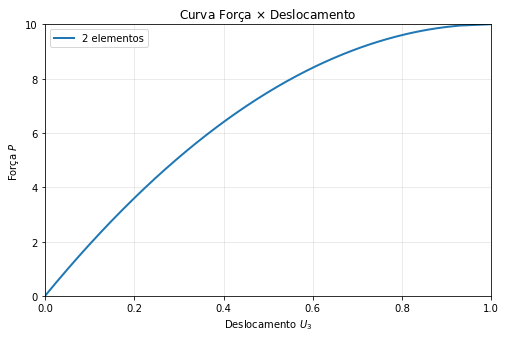

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Carga
P_plot = np.linspace(0, 10, 200)

# Deslocamento do nó 3
U3_plot = 1 - np.sqrt(1 - P_plot/10)

# Gráfico
plt.figure(figsize=(8, 5))

plt.plot(U3_plot, P_plot, linewidth=2, label='2 elementos')

plt.xlabel(r'Deslocamento $U_3$')
plt.ylabel(r'Força $P$')
plt.title(r'Curva Força $\times$ Deslocamento')

plt.xlim(0, 1)
plt.ylim(0, 10)

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()